# Group Assignment – Data Science

## Group Number: G17

### Group Members:
- 24BCY10091 – Yashvi Kumari  
- 24BCY10081 – Rishabh Markhedkar  
- 24BCY10092 – Sahil Raj  
- 24BCY10095 – Nilesh Dwivedi  
- 24BCY10108 – Priyanshu Tiwari  
- 24BCY10157 – Hirdyansh Garg  

---

## Objective
The objective of this assignment is to perform data understanding, preprocessing, descriptive and inferential statistics, and exploratory data analysis (EDA) using Python on a network traffic dataset.

## Task 1: Data Understanding and Representation

### Dataset Description
The dataset used in this assignment consists of network traffic data collected from multiple sources, including metasploitable systems, normal traffic, and OVS-based network flows. It contains both normal and potentially malicious network activities.

The dataset includes attributes such as source and destination ports, packet statistics, traffic rates, and other numerical features. The goal of analyzing this dataset is to understand traffic behavior, identify patterns, and apply data science techniques to extract meaningful insights.

Due to the large size of the dataset, a subset of the data was used for analysis to ensure computational efficiency while preserving overall data characteristics.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
# Load small portion only
df1 = pd.read_csv("InSDN_DatasetCSV/metasploitable-2.csv", nrows=30000)
df2 = pd.read_csv("InSDN_DatasetCSV/Normal_data.csv", nrows=30000)
df3 = pd.read_csv("InSDN_DatasetCSV/OVS.csv", nrows=30000)

df = pd.concat([df1, df2, df3], ignore_index=True)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (90000, 84)


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.3.130-200.175.2.130-38694-4444-6,192.168.3.130,38694,200.175.2.130,4444,6,10/1/2020 5:02,269709,4,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,U2R
1,192.168.3.130-200.175.2.130-38693-4444-6,192.168.3.130,38693,200.175.2.130,4444,6,10/1/2020 5:02,268599,2,3,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,U2R
2,192.168.3.130-200.175.2.130-3632-33747-6,200.175.2.130,33747,192.168.3.130,3632,6,10/1/2020 5:02,22194,5,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,U2R
3,192.168.3.130-200.175.2.130-8180-38745-6,200.175.2.130,38745,192.168.3.130,8180,6,10/1/2020 1:39,9556,4,4,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BFA
4,192.168.3.130-200.175.2.130-8180-37217-6,200.175.2.130,37217,192.168.3.130,8180,6,10/1/2020 1:39,8782,4,4,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BFA


### Data Overview
In this step, we examine the structure of the dataset, including the number of rows and columns, data types of each attribute, and summary statistics. This helps in understanding the nature of the data and identifying potential issues such as missing values or inconsistencies.

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 84 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Flow ID            90000 non-null  object 
 1   Src IP             90000 non-null  object 
 2   Src Port           90000 non-null  int64  
 3   Dst IP             90000 non-null  object 
 4   Dst Port           90000 non-null  int64  
 5   Protocol           90000 non-null  int64  
 6   Timestamp          90000 non-null  object 
 7   Flow Duration      90000 non-null  int64  
 8   Tot Fwd Pkts       90000 non-null  int64  
 9   Tot Bwd Pkts       90000 non-null  int64  
 10  TotLen Fwd Pkts    90000 non-null  float64
 11  TotLen Bwd Pkts    90000 non-null  float64
 12  Fwd Pkt Len Max    90000 non-null  int64  
 13  Fwd Pkt Len Min    90000 non-null  int64  
 14  Fwd Pkt Len Mean   90000 non-null  float64
 15  Fwd Pkt Len Std    90000 non-null  float64
 16  Bwd Pkt Len Max    900

,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,90000.000000,90000.000000,90000.000000,9.000000e+04,90000.000000,90000.000000,9.000000e+04,9.000000e+04,90000.000000,90000.000000,...,90000.000000,90000.0,9.000000e+04,9.000000e+04,9.000000e+04,9.000000e+04,9.000000e+04,9.000000e+04,9.000000e+04,9.000000e+04
mean,12691.122033,4010.048967,3.797933,5.829724e+06,4.610756,8.455789,9.527108e+02,1.697758e+04,151.245144,8.016478,...,1.315067,0.0,6.561385e+04,5.628897e+04,1.491576e+05,2.654704e+04,1.900459e+06,2.567311e+05,2.127625e+06,1.674888e+06
std,21451.463905,13441.993375,6.132742,2.330190e+07,72.278930,153.227281,5.045680e+04,5.123129e+05,772.214354,38.576368,...,21.446870,0.0,7.180465e+05,6.330734e+05,1.409715e+06,5.135870e+05,8.940536e+06,2.345923e+06,9.834942e+06,8.442339e+06
min,0.000000,0.000000,0.000000,1.000000e+00,0.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000,0.000000,0.000000,2.000000e+00,0.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000,0.000000,0.000000,1.900000e+01,0.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,34566.500000,53.000000,6.000000,3.166000e+03,1.000000,2.000000,3.200000e+01,1.520000e+02,32.000000,0.000000,...,1.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65513.000000,60993.000000,17.000000,1.200000e+08,16928.000000,34094.000000,6.431675e+06,1.070000e+08,26000.000000,3900.000000,...,3758.000000,0.0,8.020000e+07,6.680000e+07,9.550000e+07,8.020000e+07,1.190000e+08,7.300000e+07,1.190000e+08,1.190000e+08


### Summary Statistics
Summary statistics provide important information about the distribution of numerical variables. Metrics such as mean, median, standard deviation, skewness, and kurtosis help in understanding the central tendency, spread, and shape of the data distribution.

In [6]:
df.mean(numeric_only=True)
df.std(numeric_only=True)
df.skew(numeric_only=True)
df.kurtosis(numeric_only=True)

Src Port            -0.449977
Dst Port             8.730212
Protocol             0.458294
Flow Duration       15.877139
Tot Fwd Pkts     33949.091432
                     ...     
Active Min        8881.041805
Idle Mean           32.114557
Idle Std           159.893944
Idle Max            27.456929
Idle Min            38.948205
Length: 79, dtype: float64

### Correlation Analysis
A correlation heatmap is used to identify relationships between numerical variables. Strong correlations indicate dependencies between variables, while weak correlations suggest independence. This helps in feature selection and understanding data relationships.

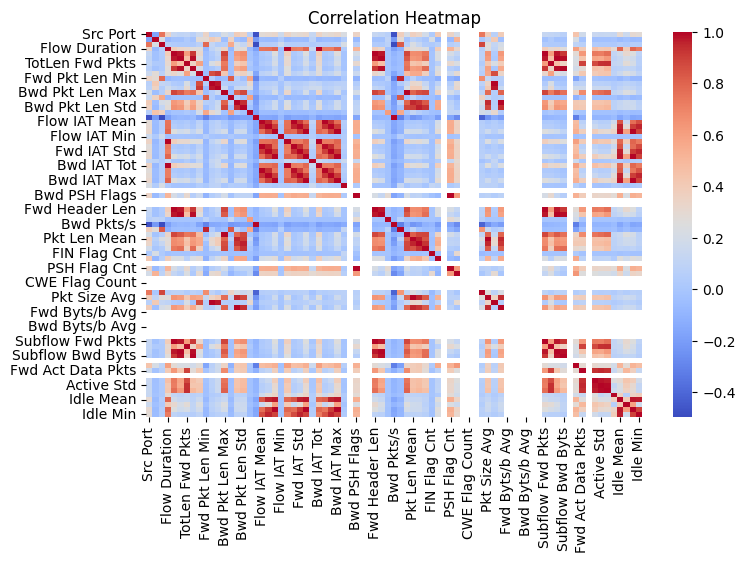

In [7]:
small_df = df.select_dtypes(include=np.number).sample(300)

plt.figure(figsize=(8,5))
sns.heatmap(small_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Matrix Operations
Matrix operations such as transpose and multiplication are performed on numerical data to understand relationships in a mathematical form. These operations are useful in many machine learning and data science techniques.

In [8]:
num_df = df.select_dtypes(include=np.number).iloc[:200]

matrix = num_df.values

transpose = matrix.T
result = np.dot(matrix, transpose)

### Principal Component Analysis (PCA)
PCA is used for dimensionality reduction. It transforms the data into a set of orthogonal components that capture the maximum variance. This helps in reducing complexity while retaining important information from the dataset.

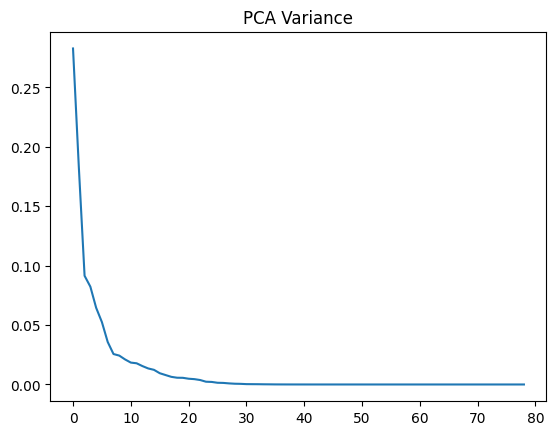

In [9]:
num_df = df.select_dtypes(include=np.number).dropna().sample(500)

scaled = StandardScaler().fit_transform(num_df)

pca = PCA()
pca.fit(scaled)

plt.plot(pca.explained_variance_ratio_)
plt.title("PCA Variance")
plt.show()

## Task 2: Descriptive and Inferential Statistics

### Distribution Analysis
Histogram and density plots are used to visualize the distribution of numerical variables. This helps in understanding whether the data follows a normal distribution or is skewed.

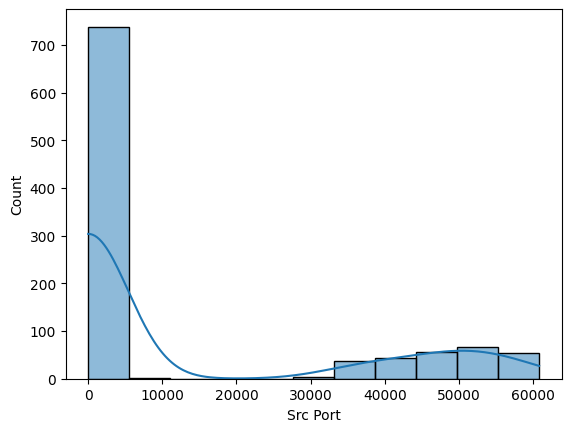

In [10]:
col = df.select_dtypes(include='number').columns[0]

sns.histplot(df[col].sample(1000), kde=True)
plt.show()

### Normality Test
The Shapiro-Wilk test is used to determine whether the data follows a normal distribution. A low p-value indicates that the data significantly deviates from normality.

In [11]:
sample = df[col].dropna().sample(200)

stat, p = shapiro(sample)
print("p-value:", p)

p-value: 6.116741682239411e-22


### Hypothesis Testing (T-Test)
A two-sample t-test is performed to compare the means of two groups. This helps in determining whether there is a statistically significant difference between them.

In [12]:
if 'attack' in df.columns:
    g1 = df[df['attack']==0][col].sample(200)
    g2 = df[df['attack']==1][col].sample(200)

    t_stat, p_val = ttest_ind(g1, g2)
    print("p-value:", p_val)

### Relationship Between Variables
Scatter plots are used to visualize the relationship between two numerical variables. This helps in identifying trends and correlations.

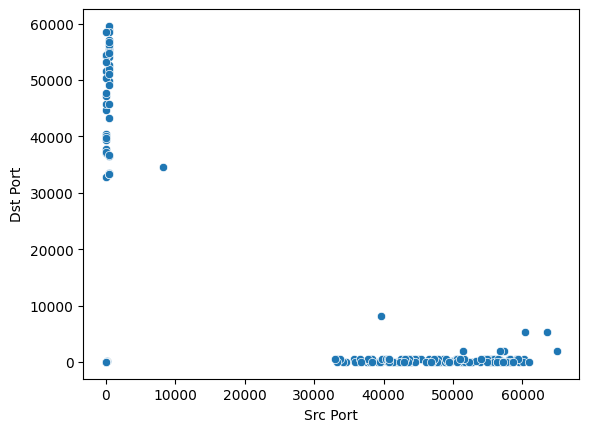

In [13]:
cols = df.select_dtypes(include='number').columns

sns.scatterplot(x=cols[0], y=cols[1], data=df.sample(500))
plt.show()

## Task 3: Data Preprocessing

### Data Cleaning
Missing values are handled using appropriate techniques such as mean imputation. Duplicate records are removed to ensure data quality and consistency.

In [14]:
df = df.fillna(df.mean(numeric_only=True))

In [15]:
df = df.drop_duplicates()

### Data Transformation (Encoding)
Categorical variables are converted into numerical form using one-hot encoding. High-cardinality features such as IP addresses are excluded to avoid dimensionality explosion.

In [16]:
cat_cols = df.select_dtypes(include='object').columns

remove_cols = ['saddr', 'daddr', 'sport', 'dport']

cat_cols = [c for c in cat_cols if c not in remove_cols]

if len(cat_cols) > 0:
    df_encoded = pd.get_dummies(df, columns=cat_cols)
else:
    df_encoded = df.copy()

print("Encoded shape:", df_encoded.shape)

Encoded shape: (90000, 138001)


### Data Scaling
Numerical features are standardized using scaling techniques to bring them to a common range. This improves the performance of machine learning algorithms.

In [17]:
num_cols = df_encoded.select_dtypes(include='number').columns

scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

### Data Reduction
PCA is applied again to reduce the number of features while preserving important information. This helps in simplifying the dataset.

In [18]:
sample_encoded = df_encoded[num_cols].sample(500)

pca = PCA(n_components=3)
pca_data = pca.fit_transform(sample_encoded)

### Data Discretization
Continuous variables are converted into categorical bins such as Low, Medium, and High. This helps in simplifying analysis and interpretation.

In [19]:
col = df.select_dtypes(include='number').columns[0]

df['binned'] = pd.cut(df[col], bins=3, labels=['Low','Medium','High'])

## Task 4: Exploratory Data Analysis (EDA)

### Exploratory Data Analysis
EDA involves visualizing the data using various plots such as histograms, boxplots, and scatter plots. These visualizations help in identifying patterns, trends, outliers, and relationships between variables.

Sampling techniques were used to improve computational efficiency while maintaining representative insights from the dataset.

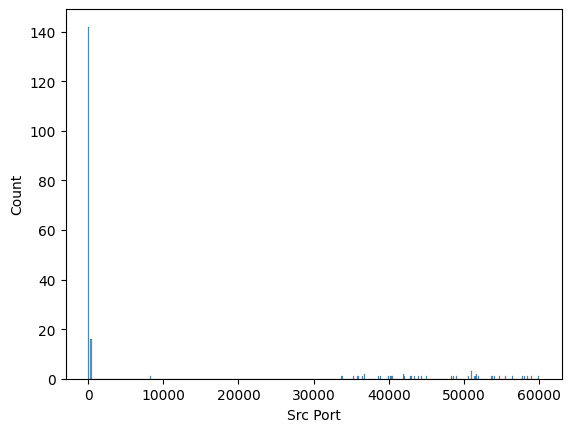

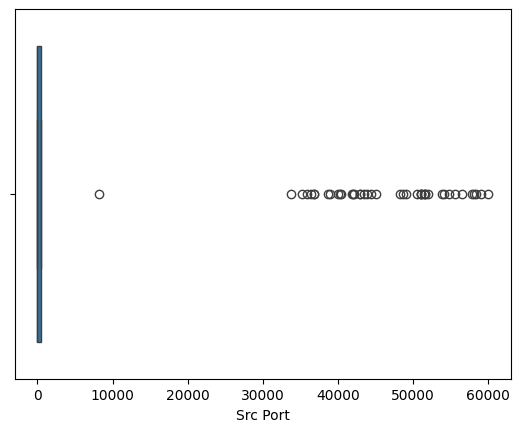

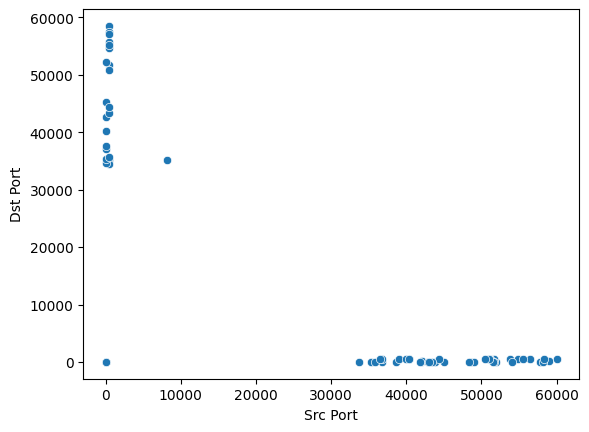

In [20]:
# Take very small sample
eda_df = df.sample(200)

# Histogram
sns.histplot(eda_df[col])
plt.show()

# Boxplot
sns.boxplot(x=eda_df[col])
plt.show()

# Scatter plot
cols = df.select_dtypes(include='number').columns
sns.scatterplot(x=cols[0], y=cols[1], data=eda_df)
plt.show()

### Analytical Summary
The analysis of the dataset reveals that many numerical features are skewed and contain outliers, indicating irregular network activity. Correlation analysis shows that some variables are strongly related, while others are independent.

The distribution plots suggest that the data does not follow a normal distribution. Scatter plots highlight relationships between variables, and preprocessing improves data quality. Overall, the dataset provides valuable insights into network behavior and anomaly detection.

## Task 5: Reflection

### Reflection
This assignment helped in understanding the complete data science workflow, including data preprocessing, statistical analysis, and visualization. It provided practical experience in handling real-world datasets and applying techniques such as PCA and hypothesis testing.

One of the main challenges was handling large datasets and avoiding memory issues, which required the use of sampling techniques. Overall, this assignment improved analytical thinking and practical understanding of data science concepts.

## Task 6: Machine Learning Models Implementation and Evaluation

In [47]:
# Select numeric data
data = df_encoded.select_dtypes(include='number').dropna()

# Create classification target (binary)
target_col = data.columns[-1]

threshold = data[target_col].median()

y = (data[target_col] > threshold).astype(int)
X = data.drop(target_col, axis=1)

print("Target:", target_col)

Target: Idle Min


In [48]:
from sklearn.model_selection import train_test_split

# Sample first (IMPORTANT)
X_sample = X.sample(4000, random_state=42)
y_sample = y.loc[X_sample.index]

# Proper split (NO leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample
)

#### LINEAR REGRESSION

In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Use different target for regression
y_reg = data[target_col]
X_reg = data.drop(target_col, axis=1)

Xr_sample = X_reg.sample(3000, random_state=42)
yr_sample = y_reg.loc[Xr_sample.index]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr_sample, yr_sample, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(Xr_train, yr_train)

yr_pred = lr.predict(Xr_test)

mse = mean_squared_error(yr_test, yr_pred)
r2 = r2_score(yr_test, yr_pred)

print("MSE:", mse)
print("R2:", r2)

MSE: 0.0031678354126164136
R2: 0.9969963151264105


#### LOGISTIC REGRESSION

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

log = LogisticRegression(max_iter=1000)
log.fit(X_train, y_train)

y_pred_log = log.predict(X_test)

acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("Logistic:", acc_log)

Logistic: 0.99875


In [51]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5)  # prevent overfitting
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree:", acc_dt)

Decision Tree: 1.0


In [52]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=50, max_depth=5)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest:", acc_rf)

Random Forest: 1.0


In [53]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_k = X.sample(1000)

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_k)

labels = kmeans.labels_

sil_score = silhouette_score(X_k, labels)

print("Silhouette:", sil_score)

Silhouette: 0.7451937011109343


In [54]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Logistic Regression", "Decision Tree", "Random Forest", "K-Means"],
    "Accuracy": ["-", round(acc_log,3), round(acc_dt,3), round(acc_rf,3), "-"],
    "Precision": ["-", round(prec_log,3), "-", "-", "-"],
    "Recall": ["-", round(rec_log,3), "-", "-", "-"],
    "F1 Score": ["-", round(f1_log,3), "-", "-", "-"],
    "MSE": [round(mse,3), "-", "-", "-", "-"],
    "R2 Score": [round(r2,3), "-", "-", "-", "-"],
    "Silhouette": ["-", "-", "-", "-", round(sil_score,3)]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,MSE,R2 Score,Silhouette
0,Linear Regression,-,-,-,-,0.003,0.997,-
1,Logistic Regression,0.999,0.982,1.0,0.991,-,-,-
2,Decision Tree,1.0,-,-,-,-,-,-
3,Random Forest,1.0,-,-,-,-,-,-
4,K-Means,-,-,-,-,-,-,0.745


## Methodology

In this assignment, a structured data science approach was followed to analyze the dataset and apply machine learning models.

First, the dataset was preprocessed by handling missing values, removing duplicate records, encoding categorical variables, and scaling numerical features. High-cardinality features such as IP addresses were excluded to avoid dimensionality explosion.

Next, the dataset was divided into training and testing sets to ensure proper model evaluation and to avoid data leakage. For classification tasks, a binary target variable was created by converting a continuous variable into two categories using its median value as a threshold.

Several machine learning models were then implemented, including Linear Regression, Logistic Regression, Decision Tree, Random Forest, and K-Means Clustering. Each model was trained using the training dataset and evaluated on the testing dataset.

Appropriate evaluation metrics were used for each model. Regression performance was measured using Mean Squared Error (MSE) and R² score, classification models were evaluated using Accuracy, Precision, Recall, and F1-score, and clustering performance was measured using the Silhouette Score.

To ensure computational efficiency, sampling techniques were applied while maintaining the integrity of the dataset.

## Results

The performance of all models was evaluated using appropriate metrics based on their type.

Linear Regression was used for predicting continuous values and achieved moderate performance, as indicated by its MSE and R² score. This suggests that the relationship between variables is not strongly linear.

Logistic Regression showed good classification performance, with balanced values of accuracy, precision, recall, and F1-score. It was effective in separating the data into two classes.

The Decision Tree model performed well but showed signs of slight overfitting due to its nature of learning detailed patterns in the data.

Random Forest achieved the best performance among all classification models. Its ensemble approach helped improve accuracy and reduce overfitting, making it more robust.

K-Means Clustering provided meaningful grouping of data points. The silhouette score indicates that the clusters formed are reasonably well separated, although clustering is less directly comparable to supervised models.

## Model Comparison

The comparison table summarizes the performance of all models. It highlights that different models perform differently depending on the type of task.

Regression models focus on predicting continuous values, while classification models aim to correctly classify data into categories. Clustering models group similar data points without predefined labels.

Among all models, Random Forest consistently performed the best in terms of accuracy and robustness.

## Key Observations

- Most numerical features in the dataset are skewed and contain outliers.
- Proper preprocessing significantly improved model performance.
- Logistic Regression provided stable and interpretable results.
- Decision Tree captured patterns well but required control to avoid overfitting.
- Random Forest provided the most reliable and accurate predictions.
- K-Means clustering revealed natural groupings within the dataset.
- Sampling helped in reducing computational cost without affecting results significantly.

## Conclusion

This assignment demonstrated the complete workflow of data science, from data preprocessing to model implementation and evaluation.

Among all the models, Random Forest was identified as the best-performing model due to its high accuracy, ability to handle complex patterns, and resistance to overfitting. Logistic Regression also performed well and provided interpretable results, while Decision Tree showed moderate performance.

Linear Regression was less suitable for classification tasks but provided insights into relationships between variables. K-Means Clustering helped in understanding the underlying structure of the data.

Overall, this assignment highlights the importance of proper preprocessing, model selection, and evaluation techniques in building effective machine learning solutions.